## Linear Regression

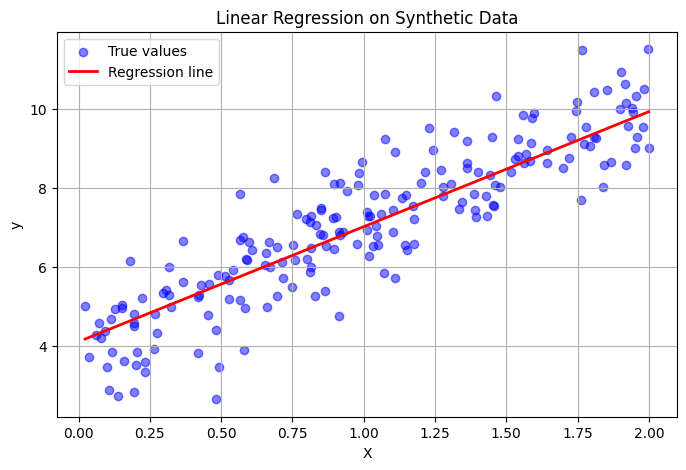

Slope (coefficient): 2.912922587415447
Intercept: 4.105855499504095
MSE: 0.7778979446150527
R2 Score: 0.7963781355012189


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ------------------------------------------------------------------------------
# Generating synthetic data
np.random.seed(0)
X = 2 * np.random.rand(1000, 1)
y = 4 + 3 * X + np.random.randn(1000, 1)

# ------------------------------------------------------------------------------
# Splitting data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------------------------
# Training model
model = LinearRegression()
model.fit(X_train, y_train)

# ------------------------------------------------------------------------------
# Predictions
y_pred = model.predict(X_test)

# ------------------------------------------------------------------------------
# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# ------------------------------------------------------------------------------
# Sorting for better plotting
sorted_idx = np.argsort(X_test[:,0])
X_test_sorted = X_test[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

# ------------------------------------------------------------------------------
# Plot
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='True values')
plt.plot(X_test_sorted, y_pred_sorted, color='red', linewidth=2, label='Regression line')

plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression on Synthetic Data")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------------------------
# Model parameters
print("Slope (coefficient):", model.coef_[0][0])
print("Intercept:", model.intercept_[0])
print("MSE:", mse)
print("R2 Score:", r2)


## Polynomial Regression

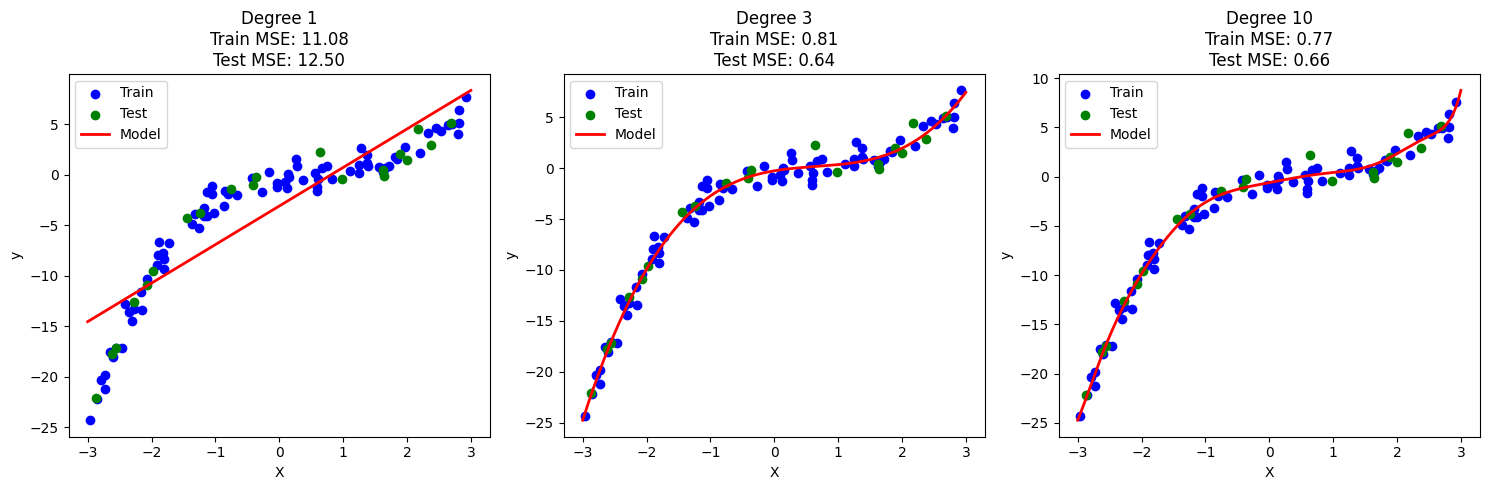

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# ---------------------------------------------------
# Generate synthetic nonlinear data
np.random.seed(42)

X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**3 - X**2 + X + np.random.randn(100, 1)

# ---------------------------------------------------
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------
degrees = [1, 3, 10]

plt.figure(figsize=(15, 5))

for i, degree in enumerate(degrees):

    # Polynomial transformation
    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Train model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # Errors
    train_error = mean_squared_error(y_train, y_train_pred)
    test_error = mean_squared_error(y_test, y_test_pred)

    # Smooth curve for plotting
    X_range = np.linspace(-3, 3, 300).reshape(-1, 1)
    X_range_poly = poly.transform(X_range)
    y_range_pred = model.predict(X_range_poly)

    # ---------------------------------------------------
    # Plot
    plt.subplot(1, 3, i + 1)

    plt.scatter(X_train, y_train, color='blue', label='Train')
    plt.scatter(X_test, y_test, color='green', label='Test')

    plt.plot(X_range, y_range_pred,
             color='red',
             linewidth=2,
             label='Model')

    plt.title(
        f'Degree {degree}\n'
        f'Train MSE: {train_error:.2f}\n'
        f'Test MSE: {test_error:.2f}'
    )

    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()

# ---------------------------------------------------
plt.tight_layout()
plt.show()


The results show that a low‑degree model underfits the data, while a very high‑degree model tends to overfit. A moderate polynomial degree provides the best balance.

Model Performance:

Linear Regression
MAE : 52.26
R²  : 0.23
------------------------------
Decision Tree
MAE : 52.39
R²  : 0.16
------------------------------
SVR
MAE : 55.19
R²  : 0.20
------------------------------
Polynomial Regression
MAE : 52.18
R²  : 0.23
------------------------------


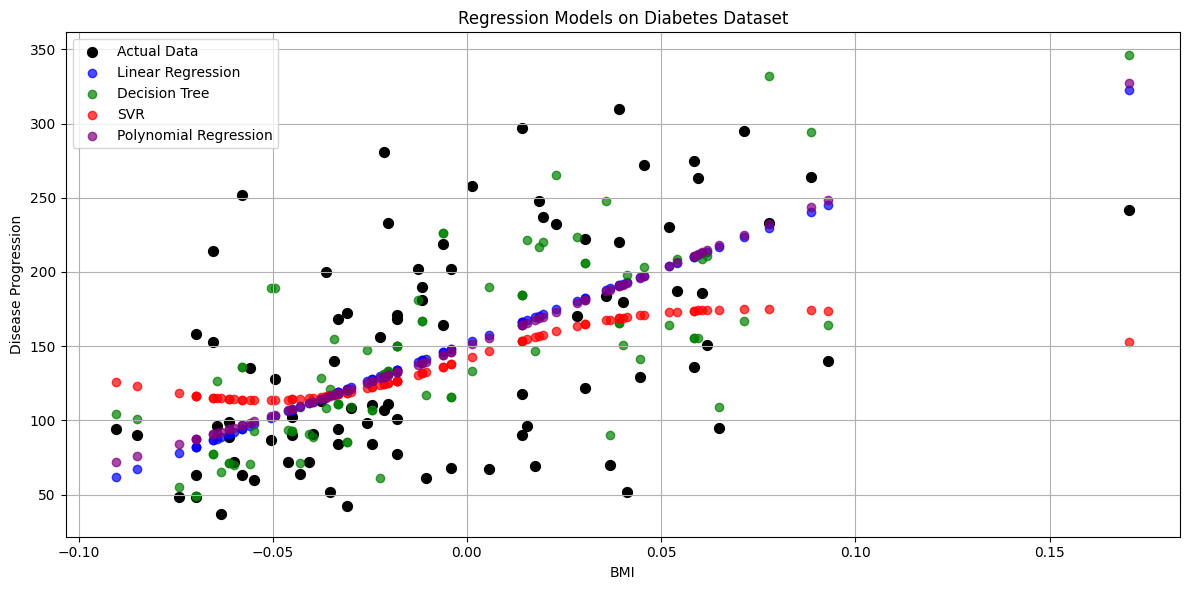

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, r2_score

# ---------------------------------------------------
# Load dataset
diabetes = load_diabetes()

data = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

data["Target"] = diabetes.target

# ---------------------------------------------------
# Select feature and target
X = data[["bmi"]].values
y = data["Target"].values

# ---------------------------------------------------
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ---------------------------------------------------
# Scale data for SVR
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------
# Initialize models
models = {
    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(random_state=42),

    "SVR":
        SVR(kernel="rbf"),

    "Polynomial Regression":
        make_pipeline(
            PolynomialFeatures(degree=3),
            LinearRegression()
        )
}

# ---------------------------------------------------
# Train models
models["Linear Regression"].fit(X_train, y_train)

models["Decision Tree"].fit(X_train, y_train)

models["SVR"].fit(X_train_scaled, y_train)

models["Polynomial Regression"].fit(X_train, y_train)

# ---------------------------------------------------
# Make predictions
predictions = {
    "Linear Regression":
        models["Linear Regression"].predict(X_test),

    "Decision Tree":
        models["Decision Tree"].predict(X_test),

    "SVR":
        models["SVR"].predict(X_test_scaled),

    "Polynomial Regression":
        models["Polynomial Regression"].predict(X_test)
}

# ---------------------------------------------------
# Evaluate models
print("Model Performance:\n")

for name, y_pred in predictions.items():

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"{name}")
    print(f"MAE : {mae:.2f}")
    print(f"R²  : {r2:.2f}")
    print("-" * 30)

# ---------------------------------------------------
# Plot predictions
plt.figure(figsize=(12, 6))

colors = {
    "Linear Regression": "blue",
    "Decision Tree": "green",
    "SVR": "red",
    "Polynomial Regression": "purple"
}

# Actual data
plt.scatter(
    X_test,
    y_test,
    color="black",
    label="Actual Data",
    s=50
)

# Model predictions
for name, y_pred in predictions.items():

    plt.scatter(
        X_test,
        y_pred,
        color=colors[name],
        label=name,
        alpha=0.7
    )

# ---------------------------------------------------
# Plot settings
plt.title("Regression Models on Diabetes Dataset")

plt.xlabel("BMI")
plt.ylabel("Disease Progression")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


**House Price**

Dataset size: 1460


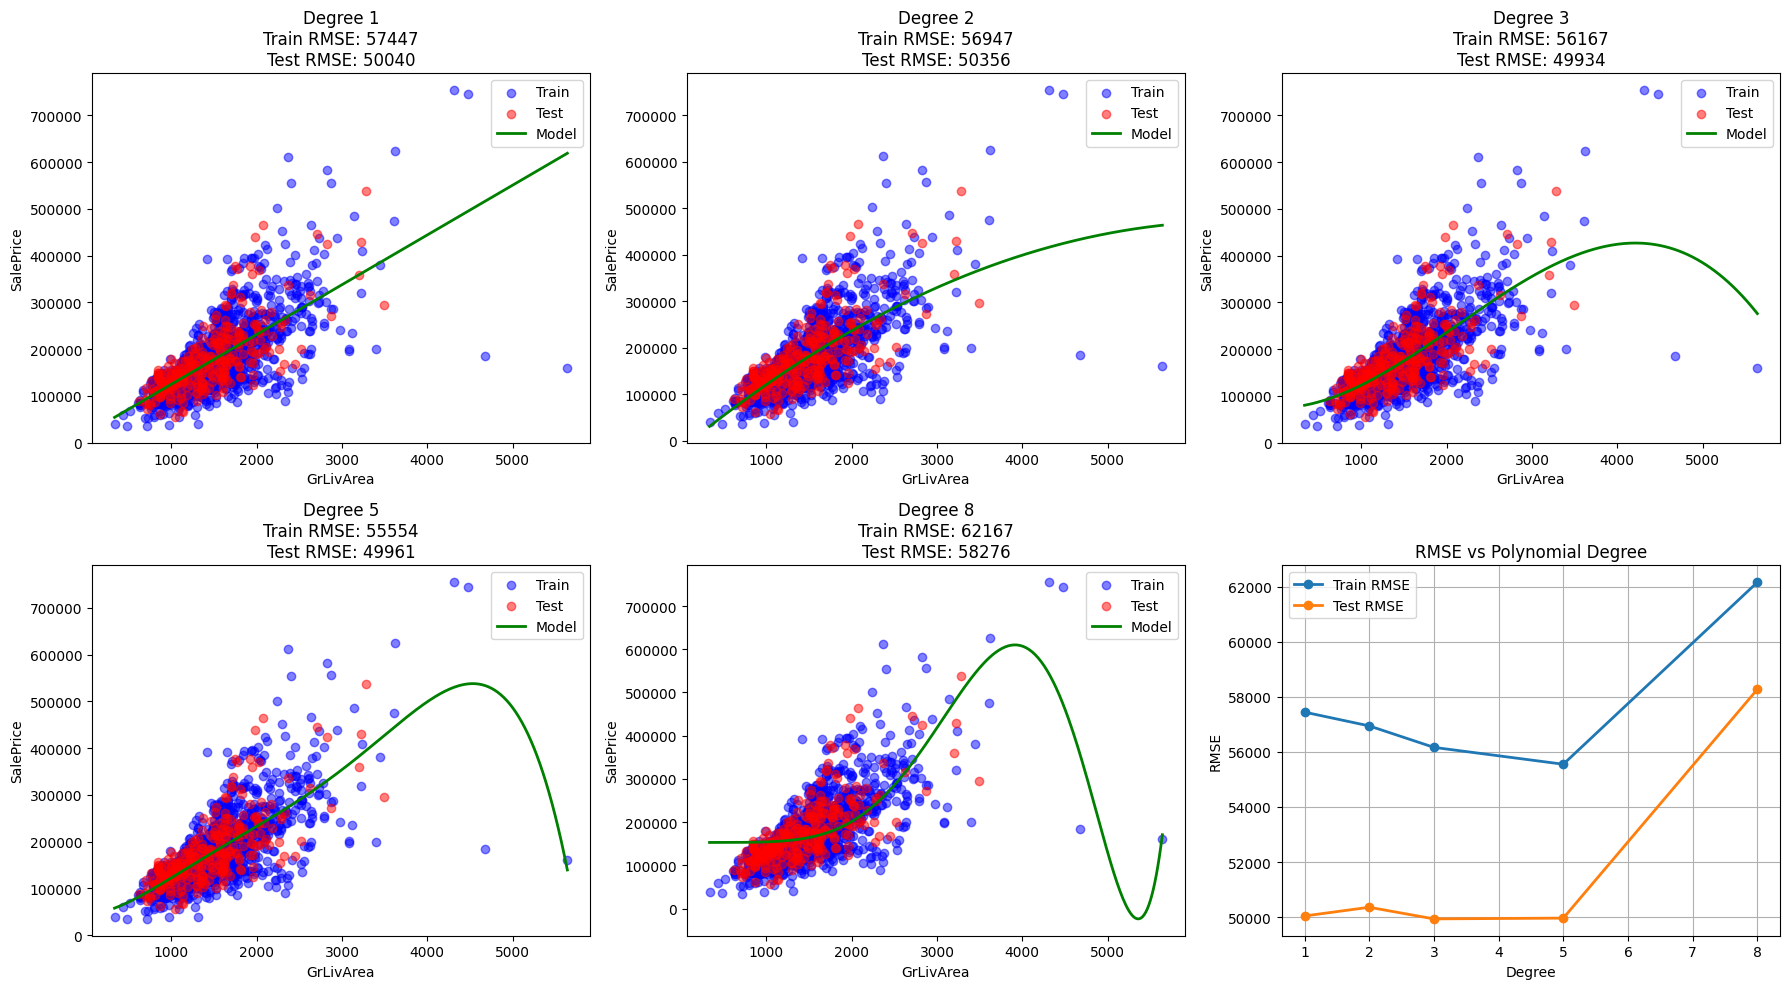

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# ---------------------------------------------------
# Load dataset
df = pd.read_csv("housePrice.csv")

# ---------------------------------------------------
# Keep only needed columns
df = df[["GrLivArea", "SalePrice"]]

# Remove missing values
df = df.dropna()

# ---------------------------------------------------
# Features and target
X = df[["GrLivArea"]].values
y = df["SalePrice"].values

print("Dataset size:", len(X))

# ---------------------------------------------------
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ---------------------------------------------------
# Polynomial degrees
degrees = [1, 2, 3, 5, 8]

train_rmse = []
test_rmse = []

# ---------------------------------------------------
# Create figure
plt.figure(figsize=(18, 10))

for i, degree in enumerate(degrees):

    # Create model
    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # RMSE
    train_error = np.sqrt(
        mean_squared_error(y_train, y_train_pred)
    )

    test_error = np.sqrt(
        mean_squared_error(y_test, y_test_pred)
    )

    train_rmse.append(train_error)
    test_rmse.append(test_error)

    # ---------------------------------------------------
    # Plot regression
    plt.subplot(2, 3, i + 1)

    plt.scatter(
        X_train,
        y_train,
        color="blue",
        alpha=0.5,
        label="Train"
    )

    plt.scatter(
        X_test,
        y_test,
        color="red",
        alpha=0.5,
        label="Test"
    )

    # Smooth curve
    X_range = np.linspace(
        X.min(),
        X.max(),
        300
    ).reshape(-1, 1)

    y_range = model.predict(X_range)

    plt.plot(
        X_range,
        y_range,
        color="green",
        linewidth=2,
        label="Model"
    )

    plt.title(
        f"Degree {degree}\n"
        f"Train RMSE: {train_error:.0f}\n"
        f"Test RMSE: {test_error:.0f}"
    )

    plt.xlabel("GrLivArea")
    plt.ylabel("SalePrice")

    plt.legend()

# ---------------------------------------------------
# RMSE comparison
plt.subplot(2, 3, 6)

plt.plot(
    degrees,
    train_rmse,
    marker="o",
    linewidth=2,
    label="Train RMSE"
)

plt.plot(
    degrees,
    test_rmse,
    marker="o",
    linewidth=2,
    label="Test RMSE"
)

plt.title("RMSE vs Polynomial Degree")

plt.xlabel("Degree")
plt.ylabel("RMSE")

plt.legend()
plt.grid(True)

# ---------------------------------------------------
plt.tight_layout()
plt.show()


For the house price dataset, low–degree polynomials (up to degree 3) slightly reduce both train and test RMSE and fit the main trend well. Higher degrees (5 and especially 8) start to overfit.